In [1]:
#Question 4.1
x =([1,2,3,10])
y = ([10, 20, 30, 40])
z=[]
for a, b in zip(x,y):
     z.append(a+b) 
print(z)

[11, 22, 33, 50]


In [2]:
z=[a + b for a, b in zip([1,2,3,10], [10, 20, 30, 40])]
print(z)

[11, 22, 33, 50]


In [3]:
x = [1,2,3,10] 
y = [10, 20, 30, 40]

def wompwomp(x,y):
    return x+y

Result = map(wompwomp, x,y)

print("Result=", list(Result))

Result= [11, 22, 33, 50]


In [7]:
#Question 4.3
import numpy as np

#input computer and input of player
you = input("Enter a choice (type R for rock, P for paper, S for scissors): ")

computer = np.array(["R", "P", "S"])
indx = np.random.randint(0, 2, 1)
cpu=computer[indx]
print("computer plays", computer[indx])


#results
if you == cpu:
    print(f"Both players selected {you}. It's a tie!")
elif you == "R":
    if cpu == "S":
        print("Rock smashes scissors! You win!")
    else:
        print("Paper covers rock! You lose.")
elif you == "P":
    if cpu == "R":
        print("Paper covers rock! You win!")
    else:
        print("Scissors cuts paper! You lose.")
elif you == "S":
    if cpu == "P":
        print("Scissors cuts paper! You win!")
    else:
        print("Rock smashes scissors! You lose.")


Enter a choice (type R for rock, P for paper, S for scissors):  S


computer plays ['P']
Scissors cuts paper! You win!


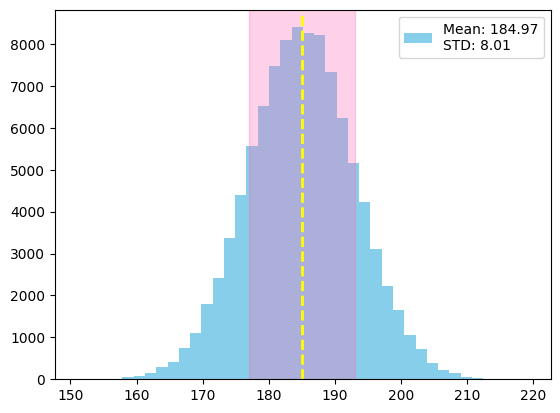

what is the chance that someone smaller than the height: 180
26.759692239990002 %
the chance that a height falls between 1 standard deviation range: 68.26894921370858 %


In [5]:
#question 4.4
%matplotlib inline
from matplotlib import pyplot as plt
import numpy as np
import scipy

lengths = np.random.normal(185, 8, 100000)
mean= np.mean(lengths)
std= np.std(lengths)

#the plot
plt.hist(lengths, bins=40, color='skyblue', label=f'Mean: {mean:.2f}\nSTD: {std:.2f}')
plt.legend()

plt.axvline(mean, color='yellow', linestyle='--', linewidth=2) #mean line
plt.axvspan(mean - std, mean + std, color='hotpink', alpha=0.3) #std shade

plt.show()

x= float(input("what is the chance that someone smaller than the height: "))
print(f"{100*scipy.stats.norm.cdf(x, mean, std)} %")

print(f"the chance that a height falls between 1 standard deviation range: {100*(scipy.stats.norm.cdf(1)-scipy.stats.norm.cdf(-1))} %")

In [ ]:
#Question 4.6
import numpy as np
from numpy import sin, cos, tan, log, log10, cosh, sinh, atan, pi

y = input("Enter a function f(x)=")
a = eval(input("the lower bound: "))
b = eval(input("the upper bound: "))

n=100000

def Monte_Carlo_integration(y, a, b, n):
    x = np.linspace(a, b, n)
    return (b - a) * np.mean(eval(y))
    
print( Monte_Carlo_integration(y, a, b, n) )

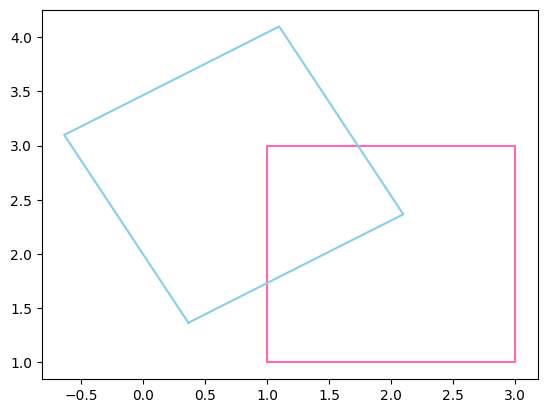

In [33]:
#Question 4.12
import math     
%matplotlib inline
from matplotlib import pyplot as plt


angle_degs = 30  
theta = math.radians(angle_degs)


rotor = math.cos(theta) + 1j*math.sin(theta)

x = np.array([1,3,3,1,1])
y = np.array([1,1,3,3,1])
minirotor = rotor * (x + 1j * y)


#plot
plt.plot(x, y, label='Vierkant', color='hotpink')  
plt.plot(minirotor.real, minirotor.imag, label='Rotated 30°', color='skyblue')         
plt.axis() 
plt.show()

In [12]:
#question 4.14
import numpy as np


def funcfilter(func, seq):
    arr = np.asarray(seq)
    filtered_arr = arr[arr > 0]
    return func(filtered_arr)

sq = np.array([-100, -10, 0, 10, 100])
result = funcfilter(np.log10, sq)
print("Result log10:", result)

Result log10: [1. 2.]


In [40]:
# Question 4.16
import numpy as np
import scipy.integrate 
from astropy.cosmology import Planck18

H0 = Planck18.H0.value
Om0 = Planck18.Om0
Ode0 = Planck18.Ode0

def H(z):
    return H0 * np.sqrt(Om0 * (1 + z)**3 + Ode0)

def function(z):
    return 1 / ((1 + z) * H(z))

def lookback_time(z):
    integral = scipy.integrate.quad(function, 0, z)[0]
    km_to_mpc = 3.086e19 
    seconds_in_gyr = 3.154e16
    t_gyr = (integral * km_to_mpc) / seconds_in_gyr
    return t_gyr
    
#for z=2
print(f"Lookback time for z=2: {lookback_time(2):.2f} Gyr")

Lookback time for z=2: 10.53 Gyr


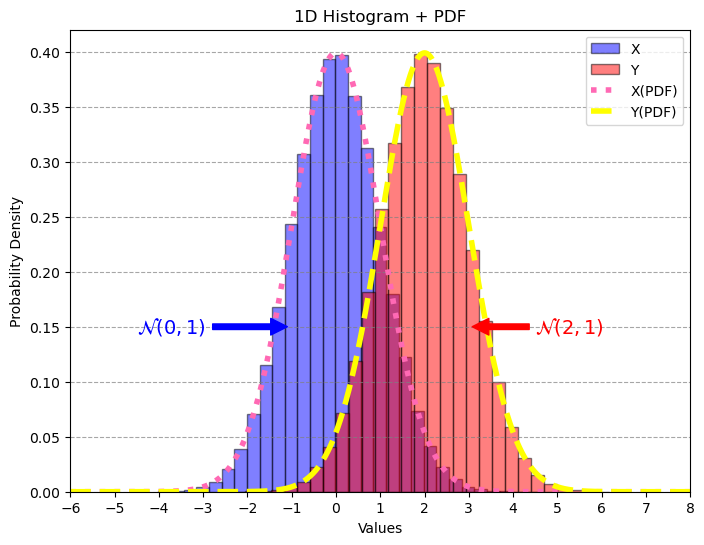

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

X = np.random.normal(loc=0, scale=1, size=100000)
Y = np.random.normal(loc=2, scale=1, size=100000)

fig, ax = plt.subplots(figsize=(8, 6))

ax.hist(X, bins=30, density=True, alpha=0.5, color='blue', edgecolor='black', label='X')
ax.hist(Y, bins=30, density=True, alpha=0.5, color='red', edgecolor='black', label='Y')

x_axis = np.linspace(-6, 8, 1000) 
#the pdf functions as lines in the plot
ax.plot(x_axis, norm.pdf(x_axis, 0, 1), color='Hotpink', linestyle=':', linewidth=4, label='X(PDF)')
ax.plot(x_axis, norm.pdf(x_axis, 2, 1), color='yellow', linestyle='--', linewidth=4, label='Y(PDF)')
# the arrows and N in the plot 
ax.annotate(r'$\mathcal{N}(0, 1)$', xy=(-1, 0.15), xytext=(-4.5, 0.15),
            color='blue', fontsize=14, va='center',
            arrowprops=dict(facecolor='blue', edgecolor='blue', width=4, headwidth=12, shrink=0.05))
ax.annotate(r'$\mathcal{N}(2, 1)$', xy=(3, 0.15), xytext=(4.5, 0.15),
            color='red', fontsize=14, va='center',
            arrowprops=dict(facecolor='red', edgecolor='red', width=4, headwidth=12, shrink=0.05))
#everything else
ax.set_title('1D Histogram + PDF')
ax.set_xlabel('Values')
ax.set_ylabel('Probability Density')
ax.set_xlim(-6, 8)
ax.set_xticks(np.arange(-6, 9, 1))
ax.set_ylim(0, 0.42)
ax.set_yticks(np.arange(0, 0.45, 0.05))
ax.grid(axis='y', linestyle='--', color='gray', alpha=0.7)
ax.legend(loc='upper right')

plt.show()

In [ ]:
#example of arrow:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))

# Draw a simple line with a peak
ax.plot([0, 1, 2], [0, 1, 0], color='black', lw=2)

# Point an arrow at the peak
ax.annotate(
    'T!',       # 1. The text
    xy=(1, 1),                 # 2. Pointing TO the peak (x=1, y=1)
    xytext=(1.5, 0.8),         # 3. Placing TEXT at (x=1.5, y=0.8)
    arrowprops=dict(           # 4. Styling the arrow
        facecolor='red',       # Fill color of the arrow
        edgecolor='darkred',   # Border color of the arrow
        width=3,               # Thickness of the arrow's tail
        headwidth=12,          # Width of the arrow's head
        shrink=0.05            # Leaves a tiny gap between the arrow and the target
    )
)

# Set some limits just to make it look nice
ax.set_xlim(0, 2.5)
ax.set_ylim(0, 1.2)

plt.show()

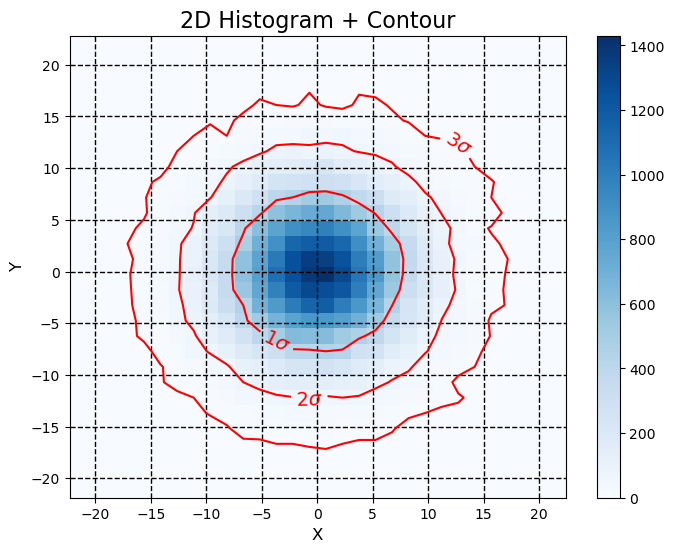

In [55]:
#histogram:
import numpy as np
import matplotlib.pyplot as plt


fig, ax = plt.subplots(figsize=(8, 6))
counts, xedges, yedges, im = ax.hist2d(X, Y, bins=30, cmap='Blues')
plt.colorbar(im, ax=ax)
counts_flat = np.sort(counts.flatten())[::-1]  
counts_cumsum = np.cumsum(counts_flat)         
total_points = counts_cumsum[-1]               

#sigma
level_1sigma = counts_flat[np.searchsorted(counts_cumsum, 0.68 * total_points)]
level_2sigma = counts_flat[np.searchsorted(counts_cumsum, 0.95 * total_points)]
level_3sigma = counts_flat[np.searchsorted(counts_cumsum, 0.997 * total_points)]

levels = [level_3sigma, level_2sigma, level_1sigma]

xcenters = (xedges[:-1] + xedges[1:]) / 2
ycenters = (yedges[:-1] + yedges[1:]) / 2
X_grid, Y_grid = np.meshgrid(xcenters, ycenters)

contour = ax.contour(X_grid, Y_grid, counts.T, levels=levels, colors='red', linewidths=1.5)

fmt = {
    level_1sigma: r'1$\sigma$',
    level_2sigma: r'2$\sigma$',
    level_3sigma: r'3$\sigma$'
}
ax.clabel(contour, inline=True, fontsize=14, fmt=fmt, colors='red')

ax.set_title('2D Histogram + Contour', fontsize=16)
ax.set_xlabel('X', fontsize=12)
ax.set_ylabel('Y', fontsize=12)

ax.grid(color='black', linestyle='--', linewidth=1)

plt.show()